## 1 - Business Understanding (Aufgabendefinition) 
- Bestimmung der betriebswirtschaftlichen Problemstellung
- Situationsbewertung
- Bestimmung analytischer Ziele
- Erstellung eines Projektplans
- ---

### Bestimmung der betriebswirtschaftlichen Problemstellung
Ein Gebrauchtwagenhändler (GWH) möchte den Preis für verfügbare Gebrauchtwagen mittels eines Modells bestimmen. Bisher wird der Preis auf Basis der Erfahrungswerte der Mitarbeiter bestimmt. Der Preis soll für die Kunden und im Vergleich zum Markt akzeptabel sein und gleichzeitig eine hohe Marge für den Händler einbringen. Durch den Einsatz einer datenbasierten Entscheidungsunterstützung soll gezeigt werden, ob es Potenzial für höhere Margen gibt. 
### Situationsbewertung
Der GWH hat Daten über verkaufte Gebrauchtwagen über die Plattform kaggle bezogen. Die Grundlage für eine Datenanalyse ist damit vorhanden. Der aktuelle Prozess ist stark von der Erfahrung der jeweiligen Mitarbeiter abhängig. Ein datenbasierter und systemgestützter Prozess könnte diese starke Abhängigkeit entlasten und die Mitarbeiter bei Ihren Entscheidungen unterstützen. Es besteht die Chance neue Erkenntnisse aus Daten zu erlangen und bisher ungenutzte Potenziale zu heben.
### Bestimmung analytischer Ziele
Identifizierung von Clustern in den Daten und deren Einfluss auf das Ziel-Attribut „Preis“ 
### Erstellung eines Projektplans
Zusammenstellen eines Teams (Rollen, Verantwortungen festlegen)
Vorgehen nach den CRISP-DM (Phasen und Dauer planen)
Ergebnisse dem Auftraggeber präsentieren

---

## 2 - Data Understanding (Datenverständniss)
- Daten sammeln
- Daten beschreiben
- Untersuchung der Daten
- Verifizierung der Datenqualität
- ---

### 2.1 Daten sammeln

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data: Based on Used Car data from https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/data

In [3]:
# Import Data sets

df = pd.read_csv("audi.csv")
#df = pd.read_csv("bmw.csv")
#df = pd.read_csv("ford.csv")

### 2.2 Daten beschreiben

In [8]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  object 
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  object 
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  object 
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 750.2+ KB


In [10]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [11]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


In [12]:
df.shape

(10668, 9)

### 2.3 Untersuchung der Daten (EDA)

### Univariate Analysis

In [16]:
def skalenniveau_bestimmen(df):
    if df.dtype == 'object':  # Kategorische Daten
        # Falls es nur wenige eindeutige Werte gibt, könnte es Nominal oder Ordinal sein.
        unique_values = df.nunique()
        if unique_values <= 10:
            return "Nominal (kategorisch)"
        else:
            return "Ordinal (Reihenfolge vorhanden)"
    
    elif pd.api.types.is_numeric_dtype(df):
        if (df.min() == 0) and (df.max() > 0):  # Echte Null vorhanden (Verhältnisskala)
            return "Verhältnisskala"
        else:  # Intervalldaten
            return "Intervallskala"
    
    return "Unklar"

# Beispiel anwenden
print('model', skalenniveau_bestimmen(df['model']))  # Nominal
print('year', skalenniveau_bestimmen(df['year']))  # Verhältnisskala
print('price', skalenniveau_bestimmen(df['price']))  # Ordinal
print('transmission', skalenniveau_bestimmen(df['transmission']))  # Nominal
print('mileage', skalenniveau_bestimmen(df['mileage']))  # Verhältnisskala
print('fuelType', skalenniveau_bestimmen(df['fuelType']))  # Nominal
print('tax', skalenniveau_bestimmen(df['tax']))  # Verhältnisskala
print('mpg', skalenniveau_bestimmen(df['mpg']))  # Verhältnisskala
print('engineSize', skalenniveau_bestimmen(df['engineSize']))  # Verhältnisskala

model Ordinal (Reihenfolge vorhanden)
year Intervallskala
price Intervallskala
transmission Nominal (kategorisch)
mileage Intervallskala
fuelType Nominal (kategorisch)
tax Verhältnisskala
mpg Intervallskala
engineSize Verhältnisskala


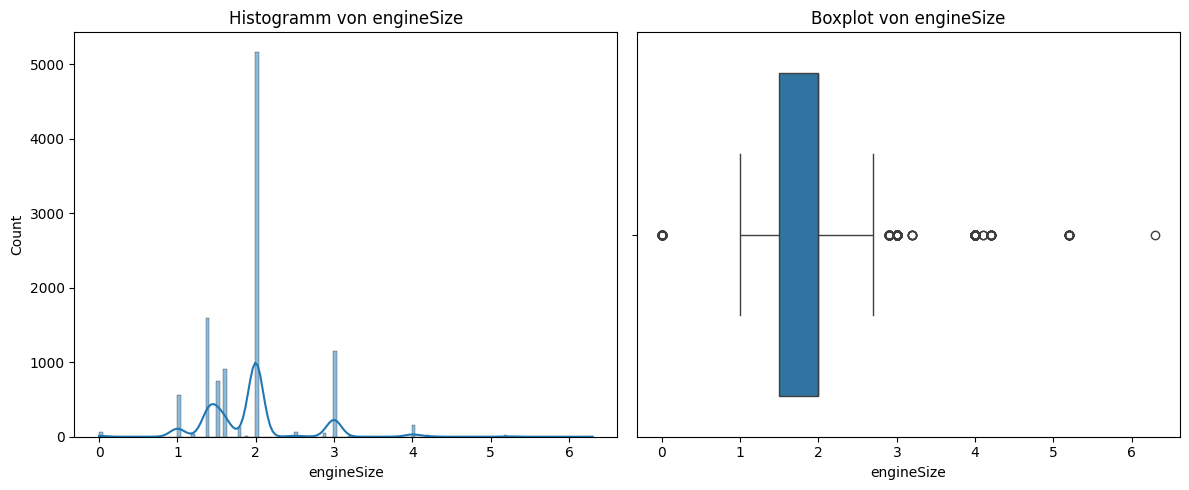

In [37]:
# Histogramm & Boxplot for numerical variables
#num_col = "year"  
#num_col = "price" 
#num_col = "mileage"  
#num_col = "tax"  
#num_col = "mpg"  
num_col = "engineSize"

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[num_col], kde=True)
plt.title(f'Histogramm von {num_col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[num_col])
plt.title(f'Boxplot von {num_col}')

plt.tight_layout()
plt.show()

model
A3     1929
Q3     1417
A4     1381
A1     1347
A5      882
Q5      877
Q2      822
A6      748
Q7      397
TT      336
A7      122
A8      118
Q8       69
RS6      39
RS3      33
RS4      31
RS5      29
R8       28
S3       18
SQ5      16
S4       12
SQ7       8
S8        4
S5        3
A2        1
RS7       1
Name: count, dtype: int64


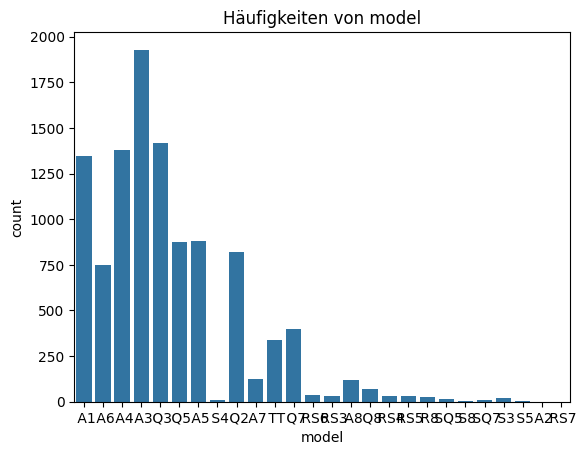

In [30]:
# for nomminal variables
cat_col = "model"
#cat_col = "transmission" 
#cat_col = "fuelType"  

print(df[cat_col].value_counts())

# Balkendiagramm
sns.countplot(x=df[cat_col])
plt.title(f'Häufigkeiten von {cat_col}')
plt.show()


### Bivariate Analysis

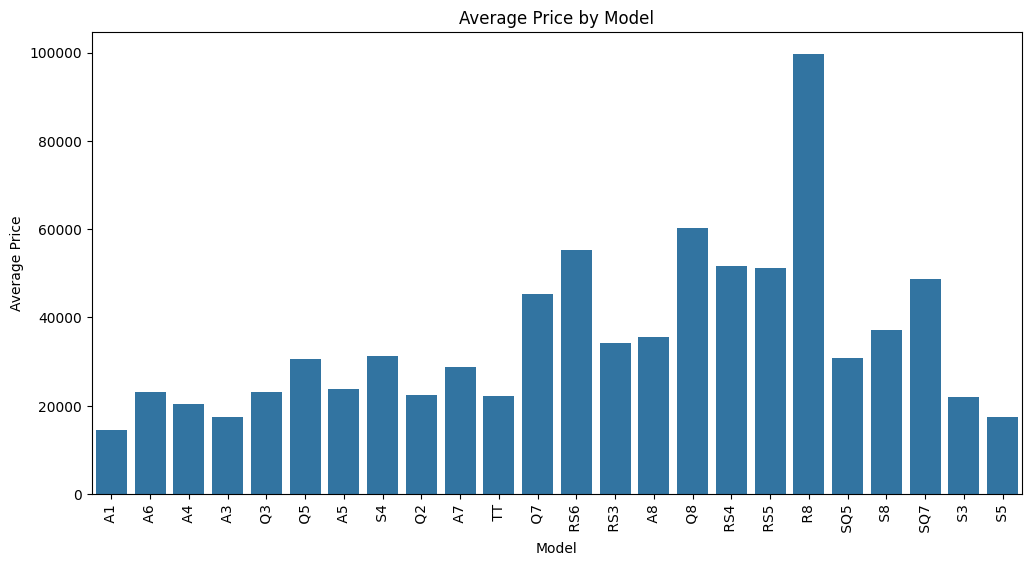

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='price', data=df[:10000], errorbar=None)
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()

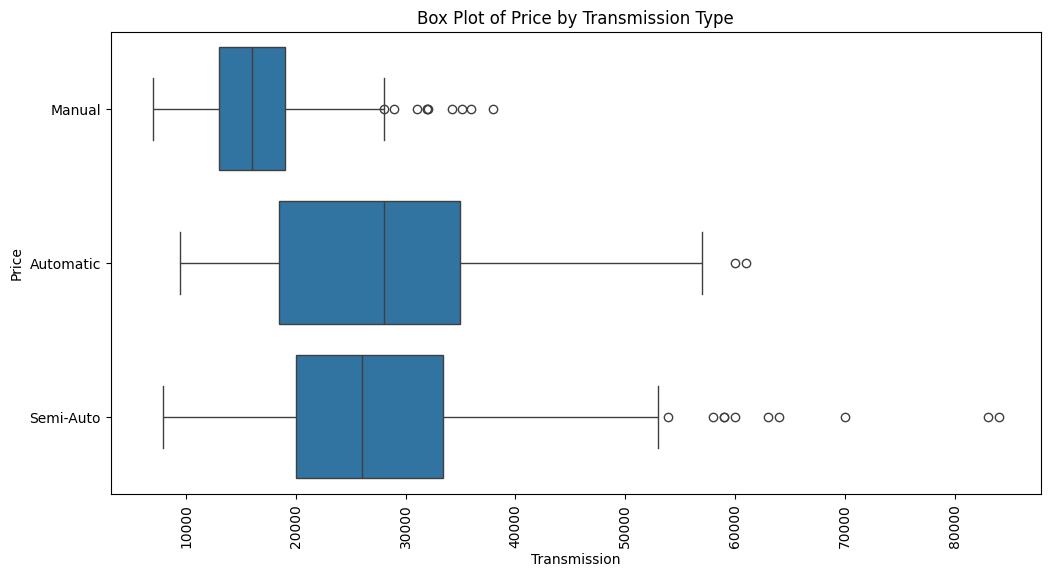

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='price', y='transmission', data=df[:1000],orient='h')
plt.title('Box Plot of Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.xticks(rotation=90) 
plt.show()

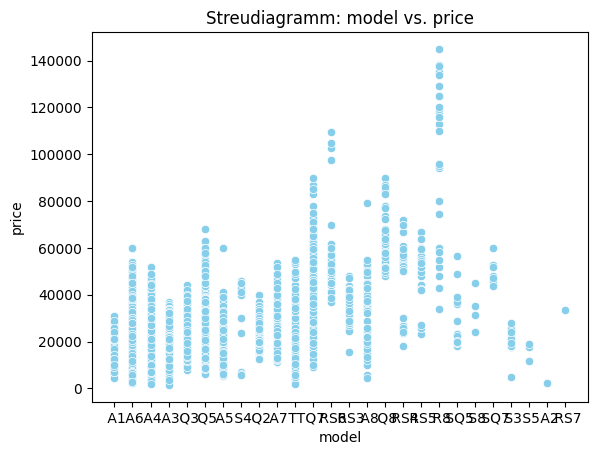

In [23]:
import seaborn as sns

# Streudiagramm mit seaborn erstellen
sns.scatterplot(data=df, x='model', y='price', color='skyblue')

# Titel hinzufügen
plt.title('Streudiagramm: model vs. price')

# Diagramm anzeigen
plt.show()

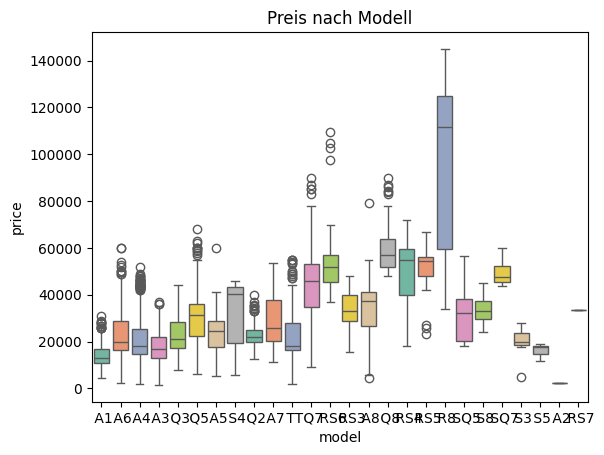

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot erstellen mit hue anstelle von palette
sns.boxplot(x='model', y='price', data=df, hue='model', palette='Set2', legend=False)

# Titel hinzufügen
plt.title('Preis nach Modell')

# Diagramm anzeigen
plt.show()

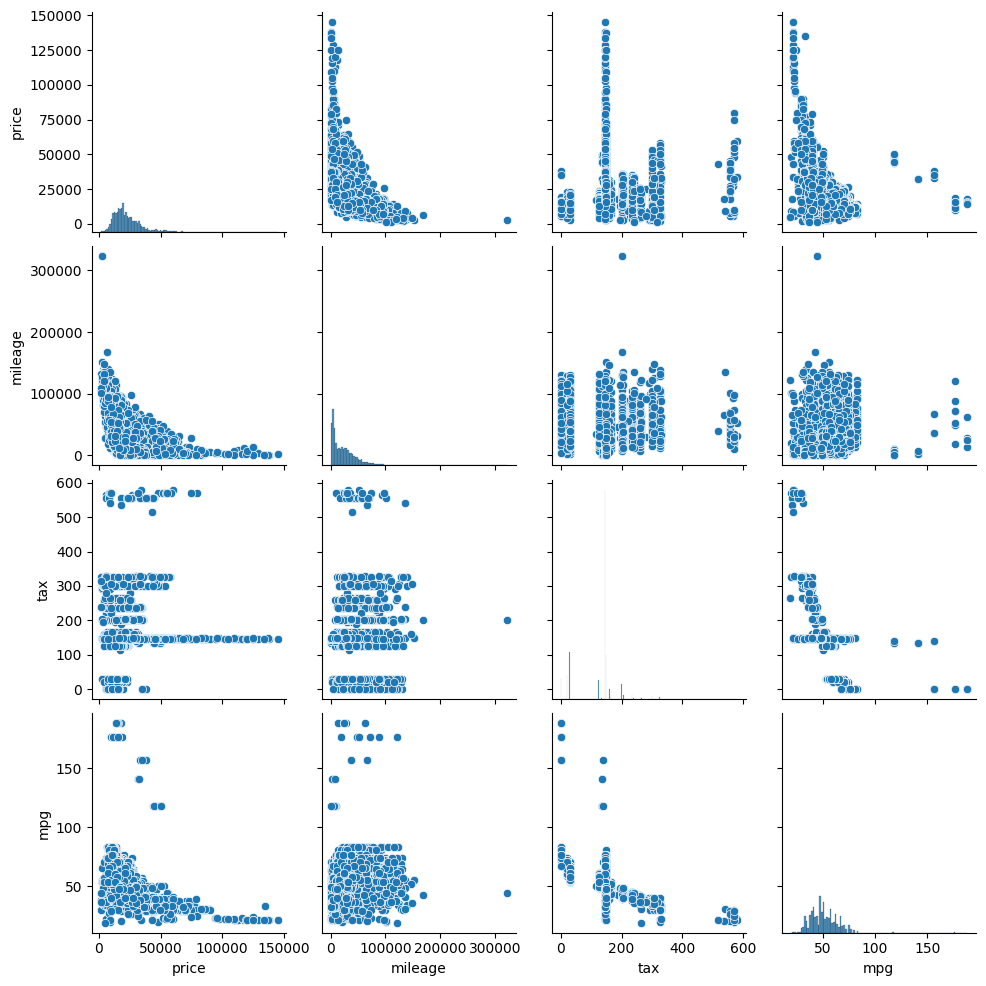

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot für price und mileage
sns.pairplot(df[['price', 'mileage', 'tax', 'transmission', 'mpg']])

# Diagramm anzeigen
plt.show()

### 2.4 Verifizierung der Datenqualität

In [4]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [5]:
# how many total missing values do we have?
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
dtype: float64


In [50]:
df.dropna()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1
...,...,...,...,...,...,...,...,...,...,...
10663,A3,2020,16999,Manual,4018,Petrol,145,49.6,1.0,1
10664,A3,2020,16999,Manual,1978,Petrol,150,49.6,1.0,1
10665,A3,2020,17199,Manual,609,Petrol,150,49.6,1.0,1
10666,Q3,2017,19499,Automatic,8646,Petrol,150,47.9,1.4,1


In [54]:
columns_with_na_dropped = df.dropna(axis=1)
columns_with_na_dropped.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1


In [55]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % df.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 10 

Columns with na's dropped: 10


In [56]:
df.fillna(0)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1
...,...,...,...,...,...,...,...,...,...,...
10663,A3,2020,16999,Manual,4018,Petrol,145,49.6,1.0,1
10664,A3,2020,16999,Manual,1978,Petrol,150,49.6,1.0,1
10665,A3,2020,17199,Manual,609,Petrol,150,49.6,1.0,1
10666,Q3,2017,19499,Automatic,8646,Petrol,150,47.9,1.4,1


In [6]:
df.duplicated().sum()

np.int64(103)

In [7]:
# Duplikate anzeigen (alle Spalten vergleichen)
duplikate = df[df.duplicated()]
print("Einfache Duplikate:")
print(duplikate)

Einfache Duplikate:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
273     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
764     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
784     Q3  2015  13995       Manual    35446   Diesel  145  54.3         2.0
967     Q5  2019  31998    Semi-Auto      100   Petrol  145  33.2         2.0
990     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
...    ...   ...    ...          ...      ...      ...  ...   ...         ...
9508    A4  2019  26990    Automatic     2250   Diesel  145  50.4         2.0
9521    Q3  2019  26990       Manual       10   Petrol  145  40.9         1.5
9529    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9550    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9597    Q3  2019  28490       Manual       10   Diesel  145  42.8         2.0

[103 rows x 9 columns]


In [8]:
# Duplikate inklusive des ersten Auftretens anzeigen
duplikate_mit_erstem = df[df.duplicated(keep=False)]
print("\nAlle Duplikate (inkl. erstes Vorkommen):")
print(duplikate_mit_erstem)


Alle Duplikate (inkl. erstes Vorkommen):
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
231     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
273     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
277     Q5  2019  31998    Semi-Auto      100   Petrol  145  33.2         2.0
567     Q3  2015  13995       Manual    35446   Diesel  145  54.3         2.0
727     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
...    ...   ...    ...          ...      ...      ...  ...   ...         ...
9524    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9529    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9549    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9550    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9597    Q3  2019  28490       Manual       10   Diesel  145  42.8         2.0

[185 rows x 9 columns

In [13]:
df_cleaned = df.drop_duplicates()

---
## 3 - Data Preparation (Datenaufbereitung)
- Auswahl der Daten
- Bereinigung der Daten
- Transformation und Integration der Daten
- Datenformatierung
- ---

### 3.1 Auswahl der Daten

### 3.2 Bereinigung der Daten

In [4]:
df_cleaned = df.drop_duplicates()

### Ausreißer nach IQR Methode

Bereinigter DataFrame:
      model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0        A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4
1        A6  2016  16500    Automatic    36203   Diesel   20  64.2         2.0
2        A1  2016  11000       Manual    29946   Petrol   30  55.4         1.4
3        A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0
4        A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0
...     ...   ...    ...          ...      ...      ...  ...   ...         ...
10663    A3  2020  16999       Manual     4018   Petrol  145  49.6         1.0
10664    A3  2020  16999       Manual     1978   Petrol  150  49.6         1.0
10665    A3  2020  17199       Manual      609   Petrol  150  49.6         1.0
10666    Q3  2017  19499    Automatic     8646   Petrol  150  47.9         1.4
10667    Q3  2016  15999       Manual    11855   Petrol  150  47.9         1.4

[10225 rows x 9 columns]


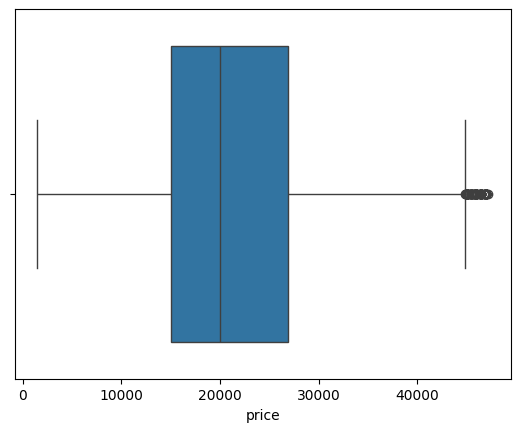

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IQR-Methode
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Grenzen für Ausreißer
untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

# Nur Zeilen behalten, die keine Ausreißer sind
df_cleaned = df[(df['price'] >= untere_grenze) & (df['price'] <= obere_grenze)]

print("Bereinigter DataFrame:")
print(df_cleaned)

# check with boxplot
sns.boxplot(x=df_cleaned['price'])
plt.show()


### Mehrere Ausreißer nach IQR Methode

In [10]:
import pandas as pd

# Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include='number').columns

# Kopie für Bereinigung
df_clean = df.copy()

# Zeilen-Indexe mit Ausreißern sammeln
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter anwenden – nur Werte innerhalb der Grenzen behalten
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(df_clean)


      model  year  price transmission  mileage fuelType  tax   mpg  \
0        A1  2017  12500       Manual    15735   Petrol  150  55.4   
3        A4  2017  16800    Automatic    25952   Diesel  145  67.3   
4        A3  2019  17300       Manual     1998   Petrol  145  49.6   
10       A3  2017  16100       Manual    28955   Petrol  145  58.9   
11       A6  2016  16500    Automatic    52198   Diesel  125  57.6   
...     ...   ...    ...          ...      ...      ...  ...   ...   
10663    A3  2020  16999       Manual     4018   Petrol  145  49.6   
10664    A3  2020  16999       Manual     1978   Petrol  150  49.6   
10665    A3  2020  17199       Manual      609   Petrol  150  49.6   
10666    Q3  2017  19499    Automatic     8646   Petrol  150  47.9   
10667    Q3  2016  15999       Manual    11855   Petrol  150  47.9   

       engineSize  model_num  
0             1.4          0  
3             2.0          3  
4             1.0          2  
10            1.4          2  
11  

### Ausreißer nach Z-Score Methode

In [ ]:
from scipy.stats import zscore

# Z-Scores berechnen
df['z_score'] = zscore(df['Wert'])

# Nur Werte mit Z-Score < 3 behalten
df_cleaned = df[df['z_score'].abs() < 3].drop(columns='z_score')

print("Bereinigter DataFrame:")
print(df_cleaned)


### 3.3  Transformation und Integration der Daten

### Label Encodig (für ordinale oder nominale Daten mit wenigen Kategorien)

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Beispiel-Daten
#df = pd.DataFrame({'Farbe': ['rot', 'blau', 'grün', 'rot', 'blau']})

# LabelEncoder anwenden
encoder = LabelEncoder()
df['model_num'] = encoder.fit_transform(df['model'])

print(df)


      model  year  price transmission  mileage fuelType  tax   mpg  \
0        A1  2017  12500       Manual    15735   Petrol  150  55.4   
1        A6  2016  16500    Automatic    36203   Diesel   20  64.2   
2        A1  2016  11000       Manual    29946   Petrol   30  55.4   
3        A4  2017  16800    Automatic    25952   Diesel  145  67.3   
4        A3  2019  17300       Manual     1998   Petrol  145  49.6   
...     ...   ...    ...          ...      ...      ...  ...   ...   
10663    A3  2020  16999       Manual     4018   Petrol  145  49.6   
10664    A3  2020  16999       Manual     1978   Petrol  150  49.6   
10665    A3  2020  17199       Manual      609   Petrol  150  49.6   
10666    Q3  2017  19499    Automatic     8646   Petrol  150  47.9   
10667    Q3  2016  15999       Manual    11855   Petrol  150  47.9   

       engineSize  model_num  
0             1.4          0  
1             2.0          5  
2             1.4          0  
3             2.0          3  
4   

### One-Hot Encoding (für nominale Daten, wenn keine Ordnung existiert)

In [11]:
# One-Hot-Encoding für die Spalte "model"
# Die encodierten Spalten dem Original-DataFrame hinzufügen
df_encoded = pd.get_dummies(df_clean, columns=['model', 'transmission', 'fuelType'])
#df_encoded = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'])

print(df_encoded)


       year  price  mileage  tax   mpg  engineSize  model_num  model_ A1  \
0      2017  12500    15735  150  55.4         1.4          0       True   
3      2017  16800    25952  145  67.3         2.0          3      False   
4      2019  17300     1998  145  49.6         1.0          2      False   
10     2017  16100    28955  145  58.9         1.4          2      False   
11     2016  16500    52198  125  57.6         2.0          5      False   
...     ...    ...      ...  ...   ...         ...        ...        ...   
10663  2020  16999     4018  145  49.6         1.0          2      False   
10664  2020  16999     1978  150  49.6         1.0          2      False   
10665  2020  17199      609  150  49.6         1.0          2      False   
10666  2017  19499     8646  150  47.9         1.4          9      False   
10667  2016  15999    11855  150  47.9         1.4          9      False   

       model_ A3  model_ A4  ...  model_ Q2  model_ Q3  model_ Q5  model_ RS3  \
0     

### 3.4 Datenformatierung

### Min-Max-Normalisierung

In [16]:
# Min-Max-Normalisierung der Gehalt-Spalte
df['mileage_norm'] = (df['mileage'] - df['mileage'].min()) / (df['mileage'].max() - df['mileage'].min())

print(df['mileage_norm'])


0        0.048712
1        0.112081
2        0.092709
3        0.080344
4        0.006183
           ...   
10663    0.012437
10664    0.006121
10665    0.001882
10666    0.026765
10667    0.036700
Name: mileage_norm, Length: 10668, dtype: float64


### Z-Score-Normalisierung 

In [17]:
# Z-Score-Normalisierung der Gehalt-Spalte
df['mileage_std'] = (df['mileage'] - df['mileage'].mean()) / df['mileage'].std()

print(df['mileage_std'])


0       -0.386817
1        0.483966
2        0.217771
3        0.047851
4       -0.971240
           ...   
10663   -0.885302
10664   -0.972091
10665   -1.030333
10666   -0.688410
10667   -0.551887
Name: mileage_std, Length: 10668, dtype: float64


### Mehrere Spalten auf einmal mit sklearn

In [38]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()  # Oder: StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print(df_scaled)

        year     price   mileage  tax       mpg  engineSize  model_num  \
0      0.625  0.137525  0.192129  0.7  0.503922    0.266667   0.000000   
3      0.625  0.245025  0.316922  0.6  0.737255    0.666667   0.157895   
4      0.875  0.257525  0.024343  0.6  0.390196    0.000000   0.105263   
10     0.625  0.227525  0.353601  0.6  0.572549    0.266667   0.105263   
11     0.500  0.237525  0.637495  0.2  0.547059    0.666667   0.263158   
...      ...       ...       ...  ...       ...         ...        ...   
10663  1.000  0.250000  0.049016  0.6  0.390196    0.000000   0.105263   
10664  1.000  0.250000  0.024099  0.7  0.390196    0.000000   0.105263   
10665  1.000  0.255000  0.007377  0.7  0.390196    0.000000   0.105263   
10666  0.625  0.312500  0.105543  0.7  0.356863    0.266667   0.473684   
10667  0.500  0.225000  0.144738  0.7  0.356863    0.266667   0.473684   

       model_ A1  model_ A3  model_ A4  ...  model_ Q3  model_ Q5  model_ RS3  \
0           True      False   

---
## 4 - Modeling (Modellierung)
- Auswahl des Modells
- Testmodell erstellen
- Modell erstellen
- ---

### 4.1  Auswahl des Modells

### 4.2 Testmodell erstellen

### 4.3 Modell erstellen

### einfaches Modell ohne transformationen

In [47]:
from sklearn.cluster import KMeans

X = df.loc[:, ["price", "mileage", "year"]]
X.head()

# Create cluster feature
kmeans = KMeans(n_clusters=6, random_state=0)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

X.head()

,price,mileage,year,Cluster
0,12500,15735,2017,2
1,16500,36203,2016,0
2,11000,29946,2016,2
3,16800,25952,2017,2
4,17300,1998,2019,1


In [64]:
import pandas as pd

# Maximale Anzahl angezeigter Spalten erhöhen
pd.set_option('display.max_columns', None)  # zeigt alle Spalten

# Optional: Zeilen auch erhöhen
pd.set_option('display.max_rows', None)


In [65]:
# Übersicht über alle numerischen Merkmale pro Cluster
cluster_summary = X.groupby('Cluster').agg(['count', 'mean', 'median', 'min', 'max'])

# Nur relevante Spalten (optional)
numerical_cols = ['mileage', 'price', 'year']
summary = X.groupby('Cluster')[numerical_cols].describe()

print(summary)


        mileage                                                           \
          count           mean           std      min       25%      50%   
Cluster                                                                    
0        1981.0   41140.576981   5984.882945  31447.0  36000.00  40494.0   
1        3878.0    5569.076328   3780.598854      5.0   2891.50   5000.0   
2        2861.0   22648.786788   5611.650425   8773.0  18200.00  22721.0   
3         914.0   65116.806346   8479.267739  52561.0  57314.75  63992.0   
4         313.0  100341.191693  19723.971084  82000.0  88000.00  95000.0   
5         721.0    8375.790569   8114.563806      1.0   3000.00   6000.0   

                               price                                       \
               75%       max   count          mean           std      min   
Cluster                                                                     
0         46048.00   55500.0  1981.0  16693.370015   5894.571212   5995.0   
1      

C:\Users\charb\AppData\Local\Temp\ipykernel_13720\2321660960.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_summary = X.groupby('Cluster').agg(['count', 'mean', 'median', 'min', 'max'])
C:\Users\charb\AppData\Local\Temp\ipykernel_13720\2321660960.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = X.groupby('Cluster')[numerical_cols].describe()


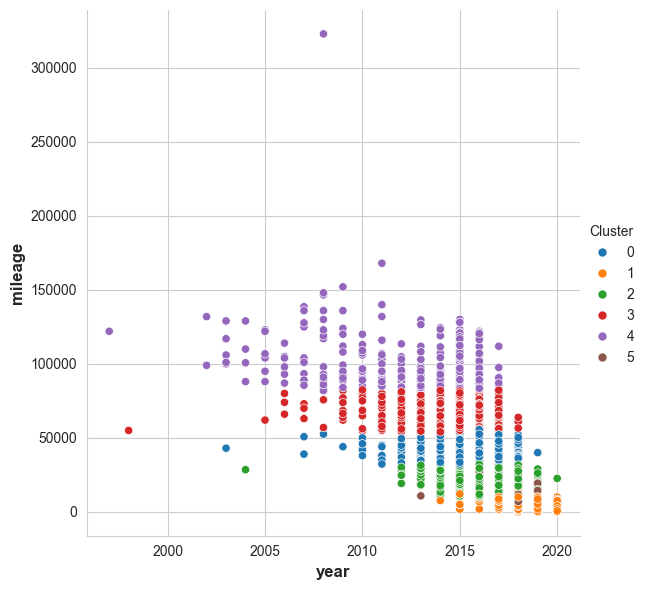

In [48]:
sns.relplot(
    x="year", y="mileage", hue="Cluster", data=X, height=6,
);

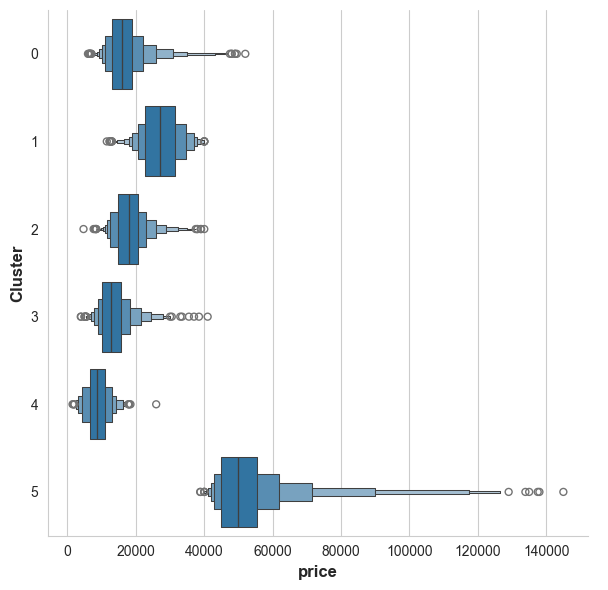

In [49]:
X["price"] = df["price"]
sns.catplot(x="price", y="Cluster", data=X, kind="boxen", height=6);

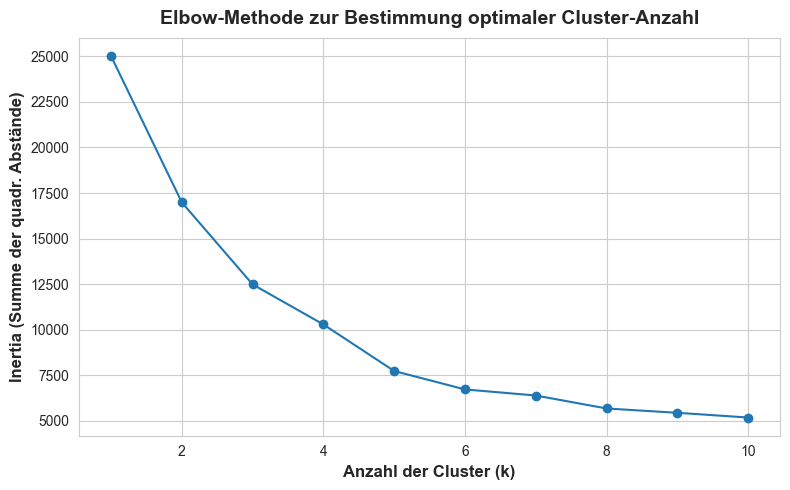

In [51]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Inertia-Werte für k = 1 bis 10 sammeln
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot erstellen
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('Inertia (Summe der quadr. Abstände)')
plt.title('Elbow-Methode zur Bestimmung optimaler Cluster-Anzahl')
plt.grid(True)
plt.show()


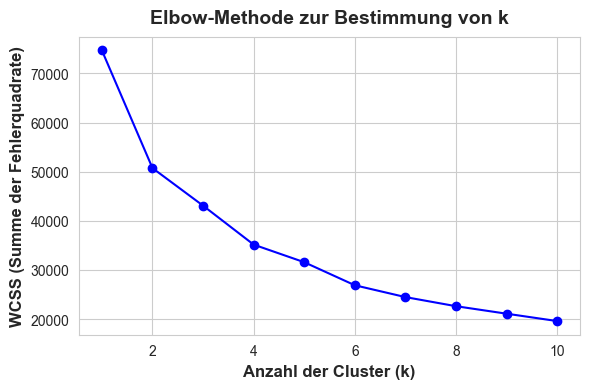

In [63]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Optional: nur numerische Spalten verwenden
numerische_daten = df.select_dtypes(include='number')

# Daten standardisieren
scaler = StandardScaler()
standardisierte_daten = scaler.fit_transform(numerische_daten)

# Elbow-Methode: verschiedene Cluster-Anzahlen ausprobieren
wcss = []  # WCSS = within-cluster sum of squares (Streuungsmaß)

k_bereich = range(1, 11)
for k in k_bereich:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(standardisierte_daten)
    wcss.append(kmeans.inertia_)  # inertia_ = Summe der quadrierten Abstände innerhalb der Cluster

# Plot der Elbow-Kurve
plt.figure(figsize=(6, 4))
plt.plot(k_bereich, wcss, 'bo-')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('WCSS (Summe der Fehlerquadrate)')
plt.title('Elbow-Methode zur Bestimmung von k')
plt.grid(True)
plt.tight_layout()
plt.show()


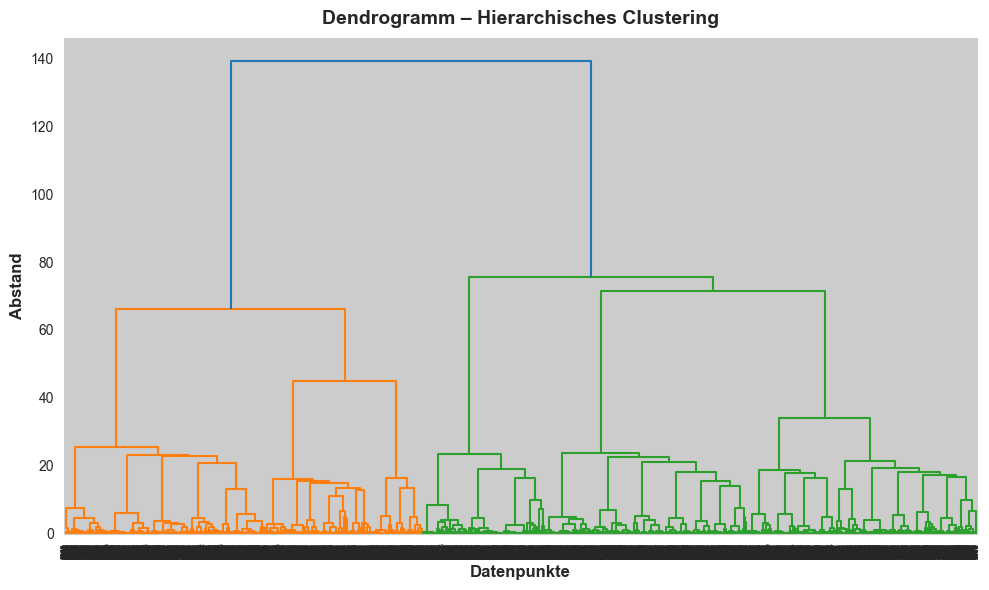

In [58]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Dendrogramm erzeugen
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))

plt.title('Dendrogramm – Hierarchisches Clustering')
plt.xlabel('Datenpunkte')
plt.ylabel('Abstand')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# 3 Cluster zuweisen (z. B. basierend auf Dendrogramm)
model = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(df_scaled)

print(df)


### Modell mit transformationen

In [44]:
from sklearn.cluster import KMeans

# Modell mit 2 Clustern
kmeans = KMeans(n_clusters=6, random_state=0)
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

#df_encoded.head()
df_scaled.head()

,year,price,mileage,tax,mpg,engineSize,model_num,model_ A1,model_ A3,model_ A4,...,model_ Q3,model_ Q5,model_ RS3,model_ S3,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Petrol,Cluster
0,0.625,0.137525,0.192129,0.7,0.503922,0.266667,0.000000,True,False,False,...,False,False,False,False,False,True,False,False,True,3
3,0.625,0.245025,0.316922,0.6,0.737255,0.666667,0.157895,False,False,True,...,False,False,False,False,True,False,False,True,False,5
4,0.875,0.257525,0.024343,0.6,0.390196,0.000000,0.105263,False,True,False,...,False,False,False,False,False,True,False,False,True,3
10,0.625,0.227525,0.353601,0.6,0.572549,0.266667,0.105263,False,True,False,...,False,False,False,False,False,True,False,False,True,3
11,0.500,0.237525,0.637495,0.2,0.547059,0.666667,0.263158,False,False,False,...,False,False,False,False,True,False,False,True,False,2


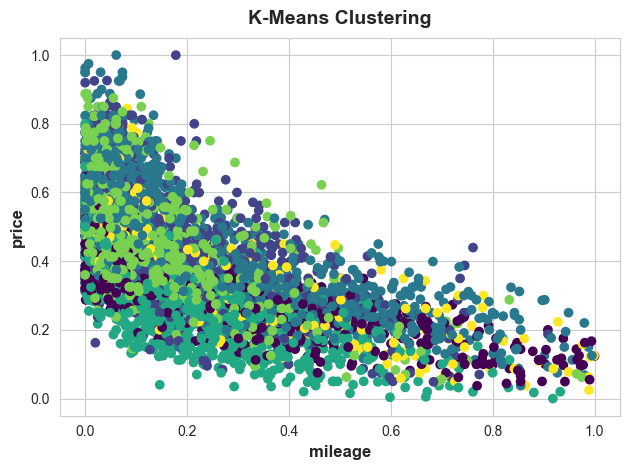

In [45]:
import matplotlib.pyplot as plt

plt.scatter(df_scaled['mileage'], df_scaled['price'], c=df_scaled['Cluster'], cmap='viridis')
plt.xlabel('mileage')
plt.ylabel('price')
plt.title('K-Means Clustering')
plt.grid(True)
plt.show()


## 5 - Evaluation (Bewertung)
- Bewertung des Modells
- Bewertung der Resultate
- Bewertung des Prozesses
- Nächste Schritte festlegen

---

### 5.1 Bewertung des Modells

### Sílhouette Score

In [72]:
from sklearn.metrics import silhouette_score

# Beispiel: X_scaled = normierte Daten, labels = Clustervorhersagen
score = silhouette_score(X, X['Cluster'])
print(f'Silhouette Score: {score:.3f}')


Silhouette Score: 0.451


### 5.2 Bewertung der Resultate

### 5.3 Bewertung des Prozesses

### 5.4 Nächste Schritte festlegen

## 6 - Deployment (Anwendung)
- Zusammenfassender Bericht und Präsentation der Ergebnisse
- Implementierungs-strategie planen
- Überwachung der Gültigkeit der Modelle planen
- ---

In [67]:
# DataFrame als CSV speichern
X.to_csv('cluster.csv', index=False)